# IND320 Project Work – Part 1

### Project links

- **By:** Agop Haroun
- **GitHub repository:** [G0KU-DOTCOM/Streamlit_dashboard](https://github.com/G0KU-DOTCOM/Streamlit_dashboard)
- **Streamlit application:** 

### AI usage

I used ChatGPT as a learning and review tool while working on this part of
the project. It helped me interpret the assignment, discuss understandable English column names, and improve the
structure and comments in the notebook. It also suggested ways to investigate
the placeholder publication date and compare measurements with different scales.
I reviewed the suggestions against the CSV outputs and official documentation
before including them. AI did not create or modify the source data, and uncertain
interpretations are identified as interpretations rather than documented facts.


In this notebook, I will prepare and explore the Norwegian reservoir
dataset before using the same data in my Streamlit app.

## 1. Importing the reservoir data

The CSV file is stored in the `data` folder, while this notebook is stored
in `notebooks`. I use a relative path instead of the full path on my
computer so the notebook can still find the data when the repository is
downloaded or cloned by someone else.

In [1]:
# I keep all imports in one cell so the notebook dependencies are easy to find.
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from IPython.display import display

In [2]:
# The two dots take me one folder back from notebooks/.
# From there, I enter the data folder and read the CSV file.
reservoirs = pd.read_csv("../data/reservoirs.csv")

# I print the dimensions first to confirm that the complete file was loaded.
print(f"The dataset contains {reservoirs.shape[0]:,} rows and {reservoirs.shape[1]} columns.")

# I create a small overview of the original headers, their data types,
# and one example value. This helps me understand what each column represents
# before I decide on clearer English names.
header_review = pd.DataFrame({
    "original_header": reservoirs.columns,
    "data_type": reservoirs.dtypes.astype(str).values,
    "example_value": [
        reservoirs[column].iloc[0]
        for column in reservoirs.columns
    ]
})

header_review

The dataset contains 14,877 rows and 11 columns.


,original_header,data_type,example_value
0,dato_Id,str,1995-09-03
1,omrType,str,EL
2,omrnr,int64,4
3,iso_aar,int64,1995
4,iso_uke,int64,35
5,fyllingsgrad,float64,0.944721
6,kapasitet_TWh,float64,21.079208
7,fylling_TWh,float64,19.913979
8,neste_Publiseringsdato,str,0001-01-01T00:00:00
9,fyllingsgrad_forrige_uke,float64,0.936888


## 2. Understanding and renaming the columns

Before changing the headers, I compare their original names, data types, and
example values. I then rename only the headers. The original observations and
official NVE area codes remain unchanged.

In [3]:
# I rename the original Norwegian headers to make the dataset easier to
# understand when I create tables, plots, and the Streamlit application.
english_names = {
    "dato_Id": "observation_date",
    "omrType": "area_type",
    "omrnr": "area_number",
    "iso_aar": "iso_year",
    "iso_uke": "iso_week",
    "fyllingsgrad": "filling_fraction",
    "kapasitet_TWh": "capacity_twh",
    "fylling_TWh": "stored_energy_twh",
    "neste_Publiseringsdato": "next_publication_date",
    "fyllingsgrad_forrige_uke": "previous_week_filling_fraction",
    "endring_fyllingsgrad": "weekly_filling_change"
}

reservoirs = reservoirs.rename(columns=english_names)

# I print the updated headers to check that every column was renamed correctly.
print(reservoirs.columns.tolist())

['observation_date', 'area_type', 'area_number', 'iso_year', 'iso_week', 'filling_fraction', 'capacity_twh', 'stored_energy_twh', 'next_publication_date', 'previous_week_filling_fraction', 'weekly_filling_change']


### Explanation of the renamed columns

I renamed the original Norwegian headers to make their meanings clearer and to
use consistent English names throughout the notebook and Streamlit application.

- **observation_date:** The date on which the reservoir level was recorded.
- **area_type:** The geographical grouping used by NVE. `EL` represents an
  electricity price area, `VASS` represents a watercourse region, and `NO`
  represents Norway as a whole.
- **area_number:** Identifies the particular area within the selected area type.
  For example, `EL` combined with area number `1` represents electricity price
  area NO1.
- **iso_year:** The year according to the ISO calendar.
- **iso_week:** The week number according to the ISO calendar.
- **filling_fraction:** The proportion of the total reservoir capacity currently
  filled. For example, `0.80` means that the reservoirs are 80% full.
- **capacity_twh:** The maximum energy-storage capacity of the reservoirs,
  measured in terawatt-hours (TWh).
- **stored_energy_twh:** The amount of energy currently stored in the reservoirs,
  measured in TWh.
- **next_publication_date:** The planned date and time for NVE's next data
  publication.
- **previous_week_filling_fraction:** The filling fraction recorded during the
  previous week.
- **weekly_filling_change:** The change in filling fraction compared with the
  previous week. For example, `0.01` corresponds to an increase of one
  percentage point.

The area codes have not been renamed because they are official identifiers used
by NVE. Their meanings were verified using the
[NVE reservoir-statistics API](https://biapi.nve.no/magasinstatistikk/swagger/index.html)
and its
[area documentation](https://biapi.nve.no/magasinstatistikk/api/Magasinstatistikk/HentOmr%C3%A5der).

## 3. Displaying and checking the data

Printing all 14,877 rows would make the notebook difficult to read. Instead,
I display the complete set of geographical areas for the first and latest
observation dates. I then summarize the structure and check for missing,
duplicated, or suspicious placeholder values.

In [ ]:
# I make a sorted copy so that the original DataFrame remains unchanged.
reservoirs_sorted = reservoirs.sort_values(
    by=["observation_date", "area_type", "area_number"]
).reset_index(drop=True)

# The publication date is repeated for every geographical area, so I keep
# one row per observation date to make the chronological pattern easier to see.
sorted_publication_dates = (
    reservoirs_sorted[
        ["observation_date", "next_publication_date"]
    ]
    .drop_duplicates()
)

# First, I inspect the beginning of the dataset.
print("First 15 observation dates:")
display(sorted_publication_dates.head(15))

# I then inspect the latest observations to compare them with the older data.
print("Last 15 observation dates:")
display(sorted_publication_dates.tail(15))

# Finally, I find the first row that contains a genuine publication date.
placeholder_date = "0001-01-01T00:00:00"

first_real_position = (
    sorted_publication_dates["next_publication_date"]
    .ne(placeholder_date)
    .to_numpy()
    .argmax()
)

# I display several rows before and after the transition.
print("Rows around the transition from placeholders to genuine dates:")

display(
    sorted_publication_dates.iloc[
        first_real_position - 8:first_real_position + 12
    ]
)

,observation_date,area_type,area_number,iso_year,iso_week,filling_fraction,capacity_twh,stored_energy_twh,next_publication_date,previous_week_filling_fraction,weekly_filling_change
0,1995-01-08,EL,1,1995,1,0.621467,6.003264,3.730831,0001-01-01T00:00:00,0.734888,-0.113421
1,1995-01-08,EL,2,1995,1,0.630947,34.043590,21.479713,0001-01-01T00:00:00,0.777604,-0.146657
2,1995-01-08,EL,3,1995,1,0.602376,8.920932,5.373754,0001-01-01T00:00:00,0.596027,0.006349
3,1995-01-08,EL,4,1995,1,0.558864,21.079208,11.780413,0001-01-01T00:00:00,0.801348,-0.242484
4,1995-01-08,EL,5,1995,1,0.616448,17.390587,10.720388,0001-01-01T00:00:00,0.614288,0.002160
...,...,...,...,...,...,...,...,...,...,...,...
14872,2026-09-06,EL,5,2026,36,0.638898,17.390587,11.110812,2026-09-16T13:00:00,0.635173,0.003725
14873,2026-09-06,NO,0,2026,36,0.636054,87.437580,55.615055,2026-09-16T13:00:00,0.634421,0.001633
14874,2026-09-06,VASS,1,2026,36,0.570397,36.044464,20.559645,2026-09-16T13:00:00,0.567087,0.003310
14875,2026-09-06,VASS,2,2026,36,0.516978,23.237715,12.013381,2026-09-16T13:00:00,0.514423,0.002555


In [15]:
# The CSV is not arranged chronologically, so I find the earliest and latest
# dates and display every area recorded on those two dates.
first_date = reservoirs["observation_date"].min()
last_date = reservoirs["observation_date"].max()

print(f"First observation date: {first_date}")
display(
    reservoirs[reservoirs["observation_date"] == first_date]
    .sort_values(["area_type", "area_number"])
)

print(f"Latest observation date: {last_date}")
display(
    reservoirs[reservoirs["observation_date"] == last_date]
    .sort_values(["area_type", "area_number"])
)

First observation date: 1995-01-08


,observation_date,area_type,area_number,iso_year,iso_week,filling_fraction,capacity_twh,stored_energy_twh,next_publication_date,previous_week_filling_fraction,weekly_filling_change
3113,1995-01-08,EL,1,1995,1,0.621467,6.003264,3.730831,0001-01-01T00:00:00,0.734888,-0.113421
7739,1995-01-08,EL,2,1995,1,0.630947,34.043590,21.479713,0001-01-01T00:00:00,0.777604,-0.146657
5036,1995-01-08,EL,3,1995,1,0.602376,8.920932,5.373754,0001-01-01T00:00:00,0.596027,0.006349
3361,1995-01-08,EL,4,1995,1,0.558864,21.079208,11.780413,0001-01-01T00:00:00,0.801348,-0.242484
3468,1995-01-08,EL,5,1995,1,0.616448,17.390587,10.720388,0001-01-01T00:00:00,0.614288,0.002160
8501,1995-01-08,NO,0,1995,1,0.608274,87.437580,53.185986,0001-01-01T00:00:00,0.752703,-0.144430
14162,1995-01-08,VASS,1,1995,1,0.636038,36.044464,22.925638,0001-01-01T00:00:00,0.798825,-0.162787
11380,1995-01-08,VASS,2,1995,1,0.608856,23.237715,14.148431,0001-01-01T00:00:00,0.744693,-0.135837
11198,1995-01-08,VASS,3,1995,1,0.566906,28.155403,15.961480,0001-01-01T00:00:00,0.661432,-0.094525


Latest observation date: 2026-09-06


,observation_date,area_type,area_number,iso_year,iso_week,filling_fraction,capacity_twh,stored_energy_twh,next_publication_date,previous_week_filling_fraction,weekly_filling_change
8260,2026-09-06,EL,1,2026,36,0.725045,6.003264,4.352634,2026-09-16T13:00:00,0.716472,0.008573
8264,2026-09-06,EL,2,2026,36,0.460863,34.043590,15.689445,2026-09-16T13:00:00,0.458999,0.001865
8262,2026-09-06,EL,3,2026,36,0.632579,8.920932,5.643190,2026-09-16T13:00:00,0.627002,0.005577
8263,2026-09-06,EL,4,2026,36,0.902762,21.079208,19.029512,2026-09-16T13:00:00,0.906918,-0.004156
8261,2026-09-06,EL,5,2026,36,0.638898,17.390587,11.110812,2026-09-16T13:00:00,0.635173,0.003725
9917,2026-09-06,NO,0,2026,36,0.636054,87.437580,55.615055,2026-09-16T13:00:00,0.634421,0.001633
14875,2026-09-06,VASS,1,2026,36,0.570397,36.044464,20.559645,2026-09-16T13:00:00,0.567087,0.003310
14876,2026-09-06,VASS,2,2026,36,0.516978,23.237715,12.013381,2026-09-16T13:00:00,0.514423,0.002555
14873,2026-09-06,VASS,3,2026,36,0.826252,28.155403,23.263466,2026-09-16T13:00:00,0.827641,-0.001389


### Data quality and area structure

The first output above shows the full geographical structure at both ends of
the time series. The following summary checks the data types, missing values,
unique values, duplicates, and the relationship between area types and area
numbers.

In [6]:
# Pandas only counts formal missing values such as NaN or None. I therefore
# count the unusual publication date separately as a possible placeholder.
placeholder_date = "0001-01-01T00:00:00"

# This compact table lets me review the structure without printing the full CSV.
column_summary = pd.DataFrame({
    "data_type": reservoirs.dtypes.astype(str),
    "pandas_missing_values": reservoirs.isna().sum(),
    "unique_values": reservoirs.nunique()
})

column_summary["placeholder_values"] = 0
column_summary.loc["next_publication_date", "placeholder_values"] = (
    reservoirs["next_publication_date"] == placeholder_date
).sum()

print(f"Completely duplicated rows: {reservoirs.duplicated().sum()}")

display(column_summary)

# Area numbers are reused, so the cross-tabulation shows which number belongs
# to each official NVE area type.
display(pd.crosstab(
    reservoirs["area_type"],
    reservoirs["area_number"],
    margins=True
))

Completely duplicated rows: 0


,data_type,pandas_missing_values,unique_values,placeholder_values
observation_date,str,0,1653,0
area_type,str,0,3,0
area_number,int64,0,6,0
iso_year,int64,0,32,0
iso_week,int64,0,53,0
filling_fraction,float64,0,14868,0
capacity_twh,float64,0,9,0
stored_energy_twh,float64,0,14871,0
next_publication_date,str,0,396,11322
previous_week_filling_fraction,float64,0,14868,0


area_number,0,1,2,3,4,5,All
area_type,,,,,,,
EL,0,1653,1653,1653,1653,1653,8265
NO,1653,0,0,0,0,0,1653
VASS,0,1653,1653,1653,0,0,4959
All,1653,3306,3306,3306,1653,1653,14877


### Checking possible placeholder values

The next two cells look for values that are technically present but may still
represent unavailable information. The histograms can reveal repeated numerical
sentinels, while the timeline shows when genuine publication dates became
available.

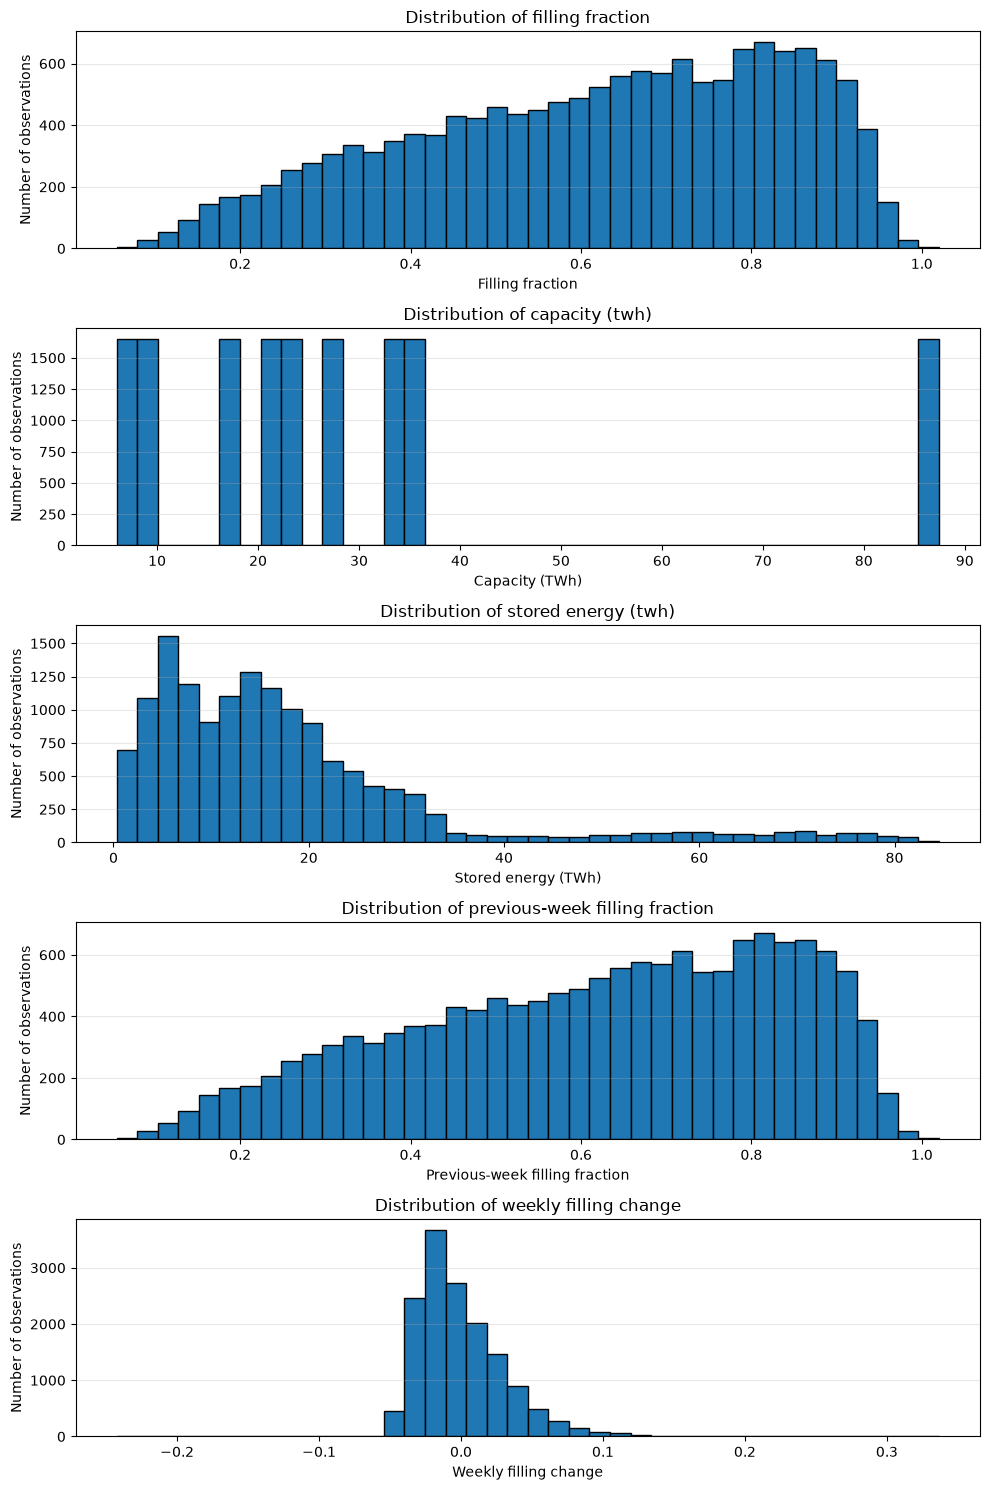

Largest energy calculation difference: 0.00001218 TWh
Largest weekly-change difference: 0.00000006
Filling fractions above 100%: 2


In [7]:
# I only include actual measurements here. Identifiers such as area number,
# ISO year, and ISO week would not be useful in this placeholder check.
measurement_columns = [
    "filling_fraction",
    "capacity_twh",
    "stored_energy_twh",
    "previous_week_filling_fraction",
    "weekly_filling_change"
]

measurement_labels = {
    "filling_fraction": "Filling fraction",
    "capacity_twh": "Capacity (TWh)",
    "stored_energy_twh": "Stored energy (TWh)",
    "previous_week_filling_fraction": "Previous-week filling fraction",
    "weekly_filling_change": "Weekly filling change"
}

fig, axes = plt.subplots(
    nrows=len(measurement_columns),
    ncols=1,
    figsize=(10, 15)
)

# A numerical placeholder would normally appear as a large isolated spike,
# often at zero or far outside the range of the real observations.
for axis, column in zip(axes, measurement_columns):
    axis.hist(
        reservoirs[column],
        bins=40,
        edgecolor="black"
    )
    axis.set_title(f"Distribution of {measurement_labels[column].lower()}")
    axis.set_xlabel(measurement_labels[column])
    axis.set_ylabel("Number of observations")
    axis.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# These calculations verify the relationships that the column names imply.
energy_difference = (
    reservoirs["stored_energy_twh"]
    - reservoirs["capacity_twh"] * reservoirs["filling_fraction"]
).abs().max()

weekly_change_difference = (
    reservoirs["weekly_filling_change"]
    - (reservoirs["filling_fraction"]
       - reservoirs["previous_week_filling_fraction"])
).abs().max()

print(f"Largest energy calculation difference: {energy_difference:.8f} TWh")
print(f"Largest weekly-change difference: {weekly_change_difference:.8f}")
print(
    "Filling fractions above 100%:",
    (reservoirs["filling_fraction"] > 1).sum()
)

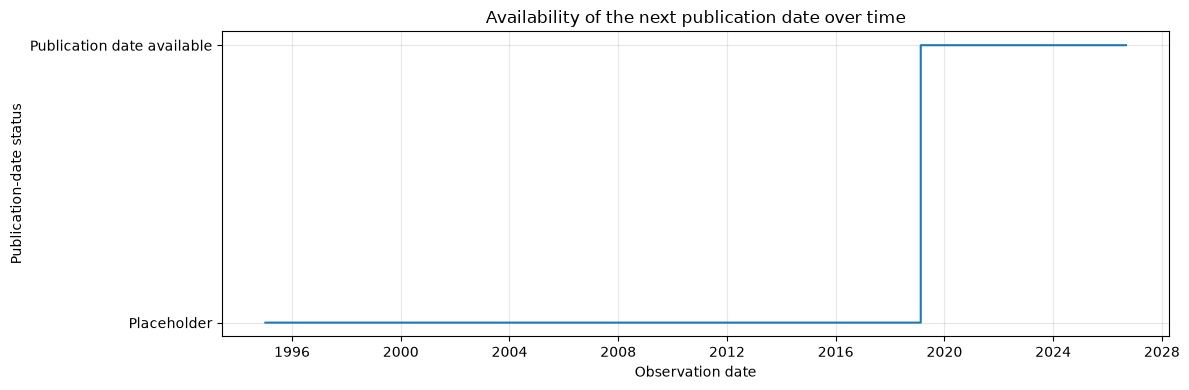

In [8]:
# The same publication date is repeated for all nine areas in each week,
# so I keep one record per observation date before creating the plot.
publication_availability = reservoirs[
    ["observation_date", "next_publication_date"]
].drop_duplicates("observation_date").copy()

publication_availability["observation_date"] = pd.to_datetime(
    publication_availability["observation_date"]
)

publication_availability["date_available"] = (
    publication_availability["next_publication_date"]
    != placeholder_date
)

publication_availability = publication_availability.sort_values(
    "observation_date"
)

plt.figure(figsize=(12, 4))
plt.step(
    publication_availability["observation_date"],
    publication_availability["date_available"].astype(int),
    where="post"
)

plt.yticks(
    [0, 1],
    ["Placeholder", "Publication date available"]
)
plt.xlabel("Observation date")
plt.ylabel("Publication-date status")
plt.title("Availability of the next publication date over time")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Missing values and placeholder dates

Pandas reports no missing values because every cell contains a stored value.
However, this does not necessarily mean that every value contains useful
information.

The `next_publication_date` column contains the value
`0001-01-01T00:00:00` in 11,322 rows. Pandas treats this as an ordinary string,
so it is not included when `isna()` counts missing values. The date is the
minimum and default `DateTime` value used by .NET, which suggests that the field
was left uninitialized when no publication date was available. It should
therefore be understood as a placeholder rather than a genuine date. Microsoft
documents this value as [`DateTime.MinValue`](https://learn.microsoft.com/dotnet/api/system.datetime.minvalue).

NVE documents the column as the next publication date, but its API
documentation does not explicitly explain the placeholder. I have therefore
kept the original values unchanged and counted them separately instead of
silently replacing them. If the column is used later in the analysis or
Streamlit application, the placeholder can be converted to a missing value or
displayed as `Not available`.

I also checked whether other columns might contain artificial values used in
place of missing data. The numerical distributions do not show any repeated
extreme values such as `-999` or unexpected zeros. The measurement columns are
also internally consistent: stored energy corresponds to capacity multiplied
by filling fraction, and weekly change corresponds to the difference between
the current and previous filling fractions.

Two filling fractions are slightly above 1.0, meaning slightly above 100%.
These values may require further investigation, but they do not resemble
placeholders because they are not repeated and the related energy values remain
mathematically consistent. I therefore kept them unchanged.

Based on these checks, `0001-01-01T00:00:00` is the only clear placeholder in
the dataset. It appears through 10 February 2019, while genuine publication
dates begin on 17 February 2019. I interpret it as an unavailable publication
date, but I do not claim to know why NVE started populating the field at that
particular point.

## 4. Plotting each column separately

Not every column represents the same kind of information. I use frequency bars
for dates, categories, years, and weeks, and time-series lines for the reservoir
measurements. For the measurement plots I use the national total (`NO`) so that
different and overlapping geographical summaries are not joined into one line.
The fractions are formatted as percentages for readability, but their underlying
values are not changed.

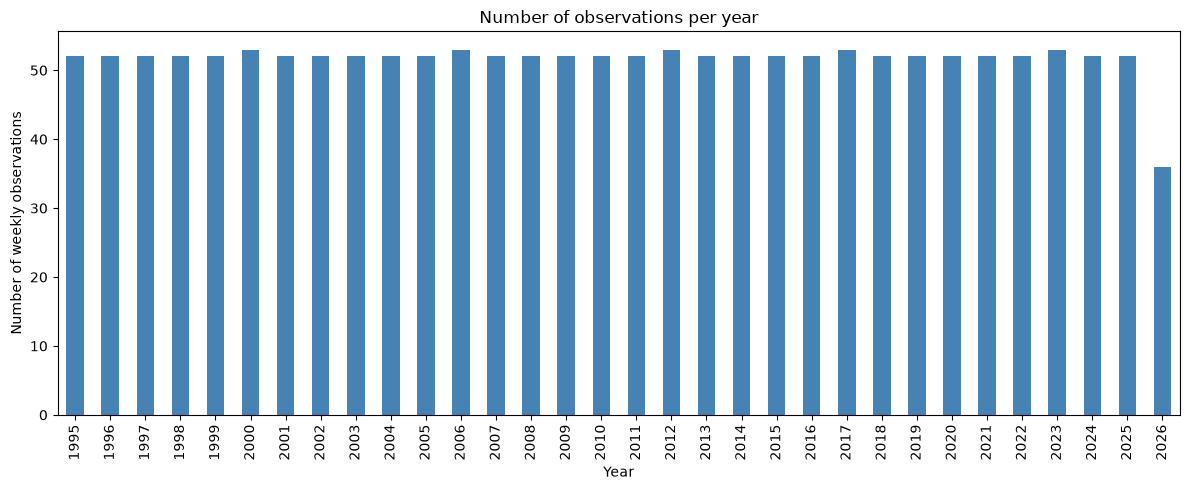

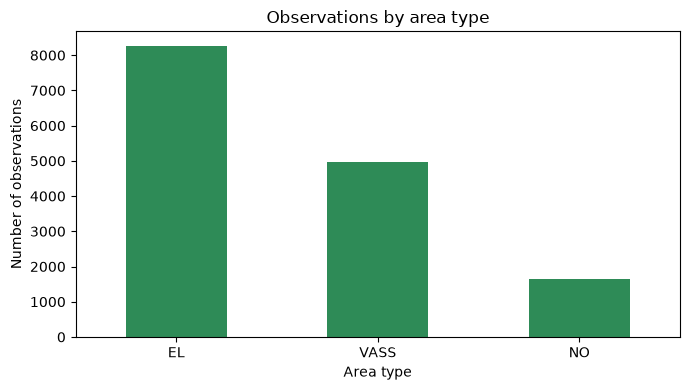

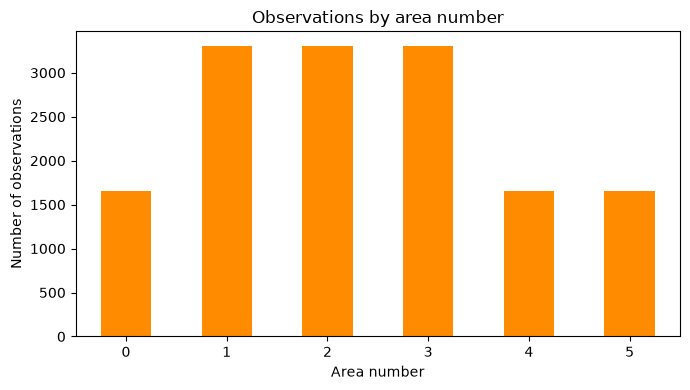

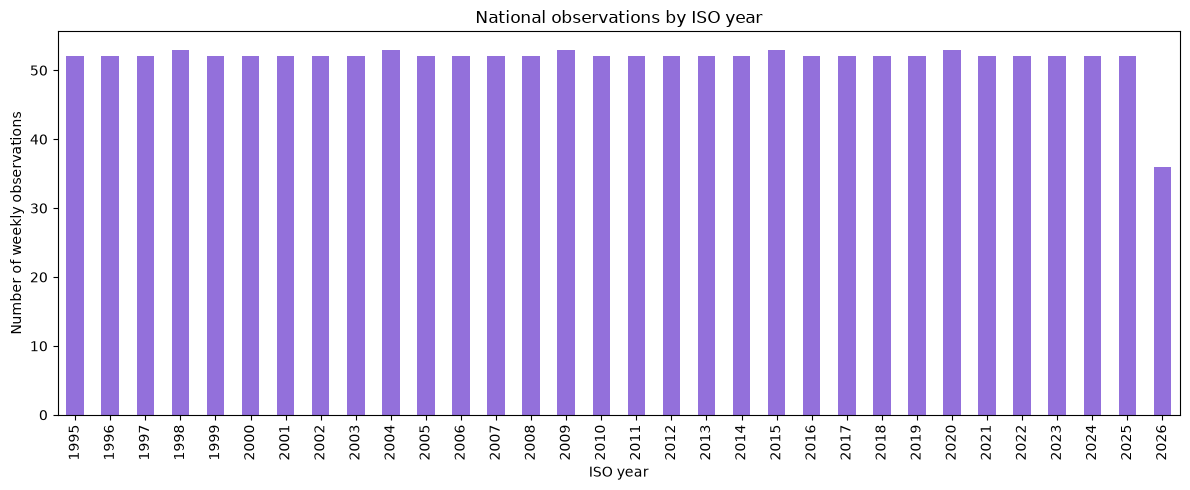

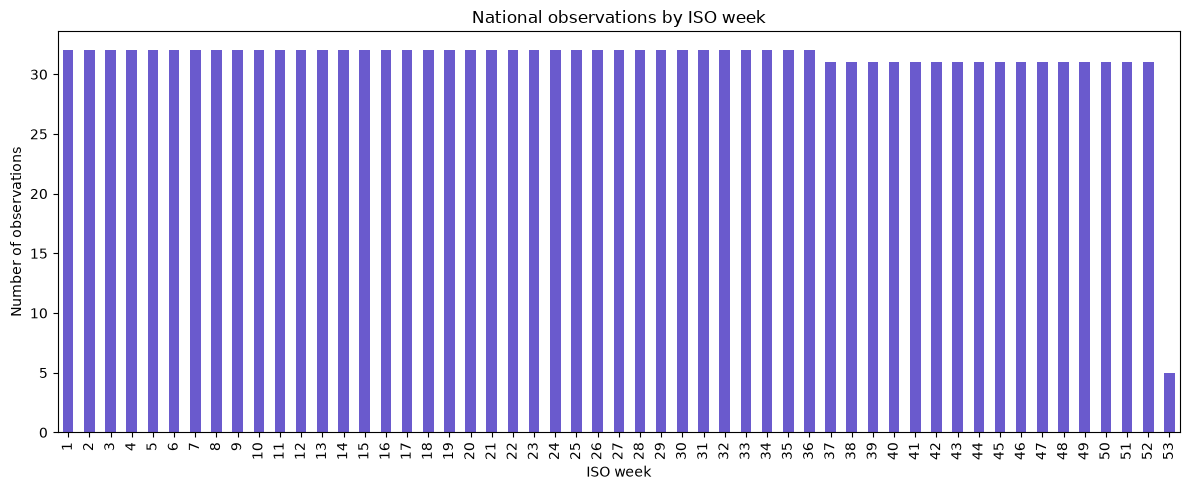

In [9]:
# I create a separate copy for plotting so that converting the date does not
# change the original imported dataset.
plot_data = reservoirs.copy()

plot_data["observation_date"] = pd.to_datetime(
    plot_data["observation_date"]
)

# The dataset contains several overlapping geographical groupings. I use the
# national total for the time-series plots so that each date appears only once.
national_data = (
    plot_data[plot_data["area_type"] == "NO"]
    .sort_values("observation_date")
)

# observation_date: number of national observations recorded per year
observations_per_year = (
    national_data["observation_date"]
    .dt.year
    .value_counts()
    .sort_index()
)

observations_per_year.plot(
    kind="bar",
    figsize=(12, 5),
    color="steelblue"
)
plt.title("Number of observations per year")
plt.xlabel("Year")
plt.ylabel("Number of weekly observations")
plt.tight_layout()
plt.show()


# area_type: number of rows belonging to each geographical grouping
reservoirs["area_type"].value_counts().plot(
    kind="bar",
    figsize=(7, 4),
    color="seagreen"
)
plt.title("Observations by area type")
plt.xlabel("Area type")
plt.ylabel("Number of observations")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# area_number: area numbers are reused across different area types
reservoirs["area_number"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(7, 4),
    color="darkorange"
)
plt.title("Observations by area number")
plt.xlabel("Area number")
plt.ylabel("Number of observations")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# iso_year: number of national observations in each ISO year
national_data["iso_year"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(12, 5),
    color="mediumpurple"
)
plt.title("National observations by ISO year")
plt.xlabel("ISO year")
plt.ylabel("Number of weekly observations")
plt.tight_layout()
plt.show()


# iso_week: frequency of the different ISO week numbers
national_data["iso_week"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(12, 5),
    color="slateblue"
)
plt.title("National observations by ISO week")
plt.xlabel("ISO week")
plt.ylabel("Number of observations")
plt.tight_layout()
plt.show()

### Reservoir measurements over time

The next cell creates one separate time-series figure for each measurement.
Keeping the figures separate preserves their original units and makes small
changes visible before the columns are compared in one combined plot.

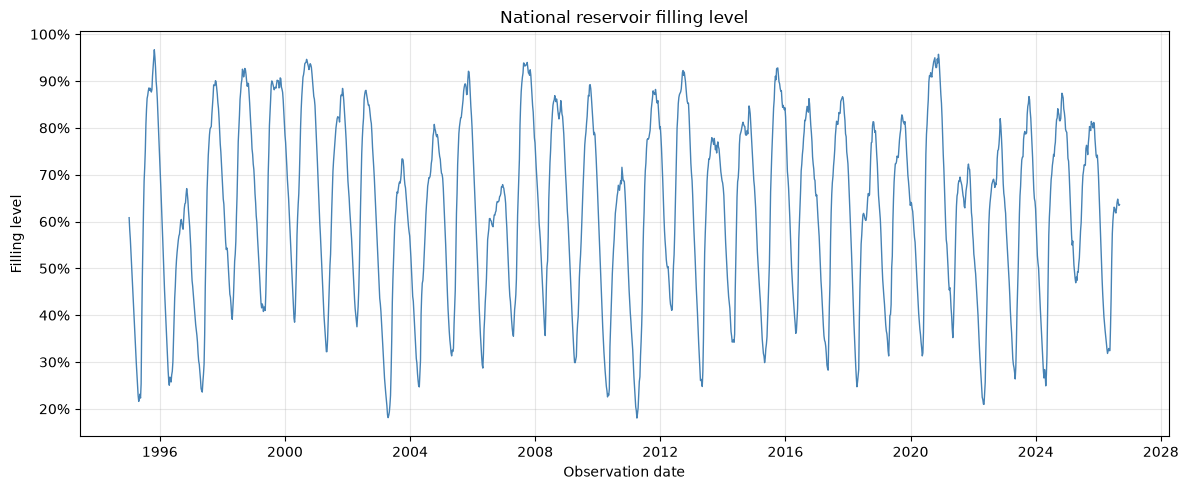

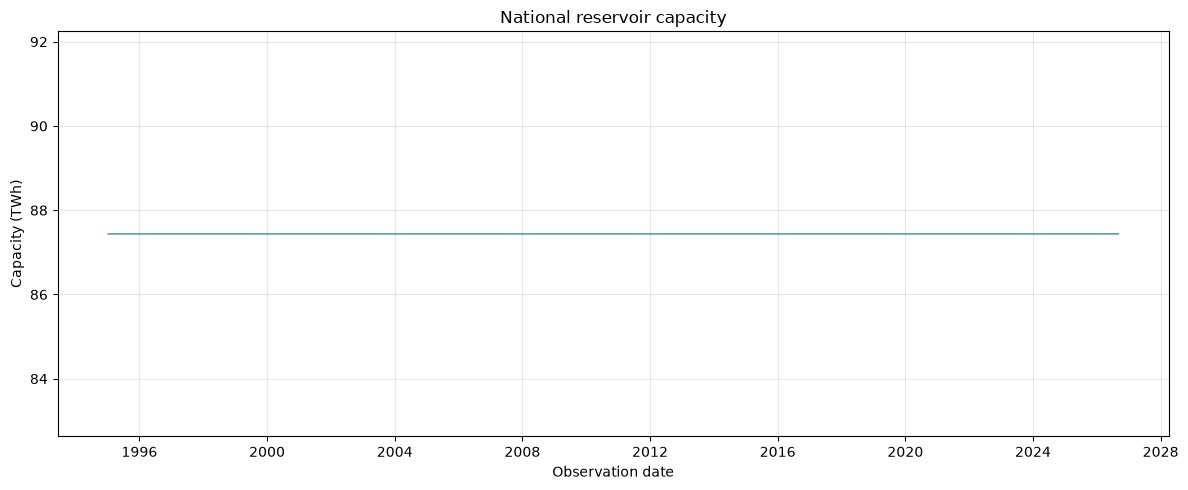

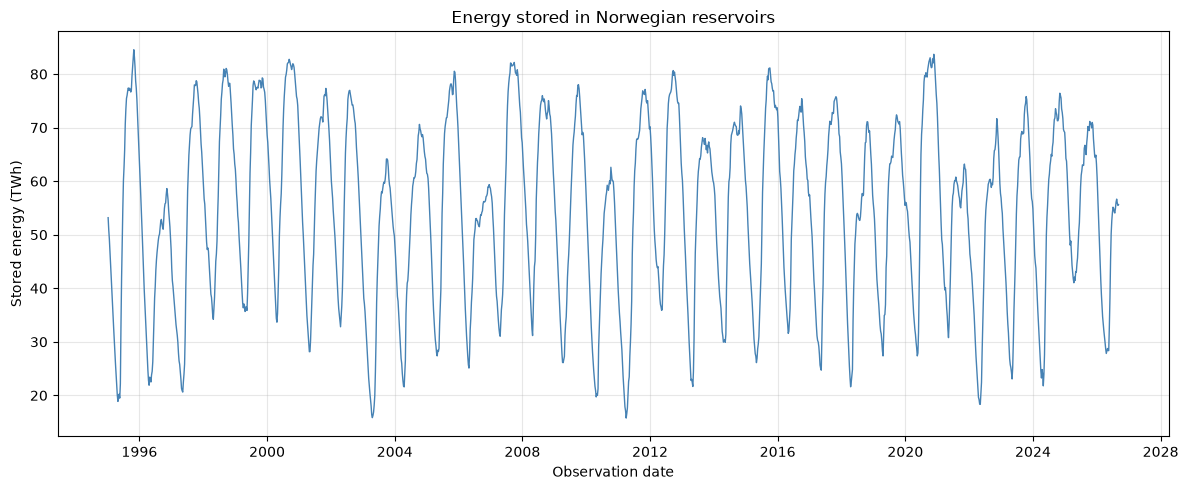

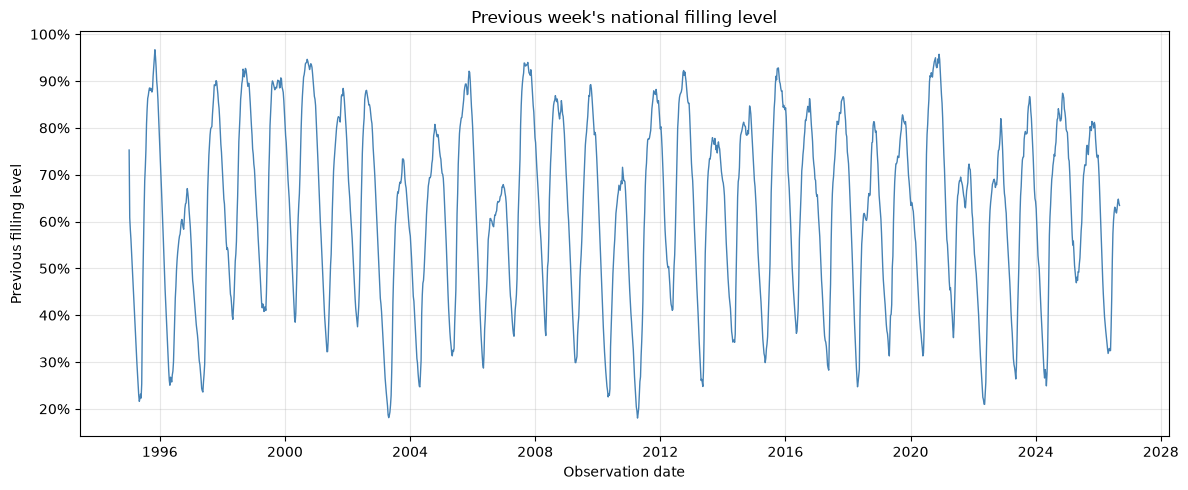

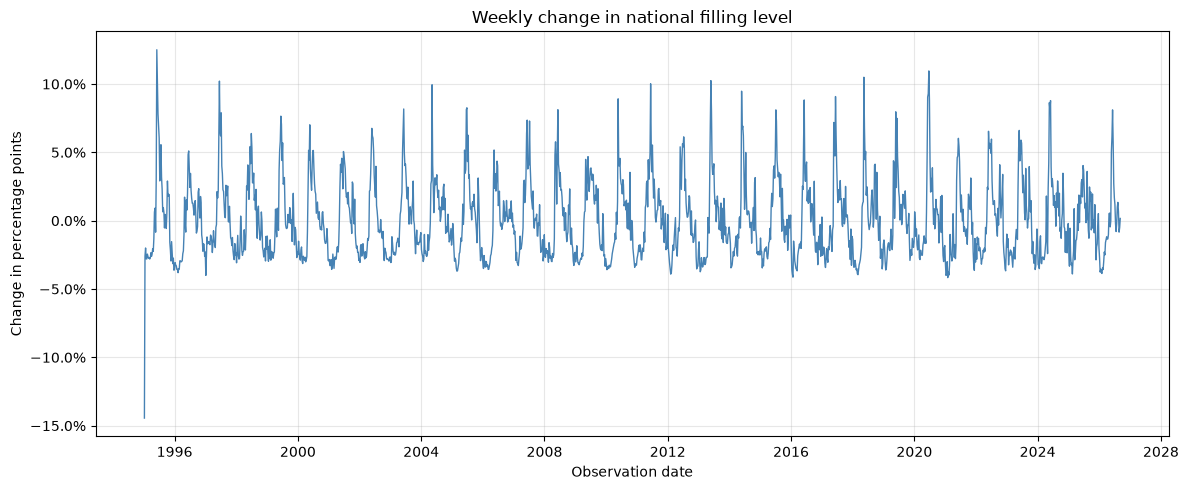

In [10]:
# Each measurement gets its own plot because the columns use different units
# and scales. The fraction columns are formatted as percentages without
# changing their underlying values.
measurement_plots = {
    "filling_fraction": {
        "title": "National reservoir filling level",
        "ylabel": "Filling level",
        "percentage": True
    },
    "capacity_twh": {
        "title": "National reservoir capacity",
        "ylabel": "Capacity (TWh)",
        "percentage": False
    },
    "stored_energy_twh": {
        "title": "Energy stored in Norwegian reservoirs",
        "ylabel": "Stored energy (TWh)",
        "percentage": False
    },
    "previous_week_filling_fraction": {
        "title": "Previous week's national filling level",
        "ylabel": "Previous filling level",
        "percentage": True
    },
    "weekly_filling_change": {
        "title": "Weekly change in national filling level",
        "ylabel": "Change in percentage points",
        "percentage": True
    }
}

for column, settings in measurement_plots.items():
    fig, axis = plt.subplots(figsize=(12, 5))

    axis.plot(
        national_data["observation_date"],
        national_data[column],
        color="steelblue",
        linewidth=1
    )

    axis.set_title(settings["title"])
    axis.set_xlabel("Observation date")
    axis.set_ylabel(settings["ylabel"])
    axis.grid(alpha=0.3)

    if settings["percentage"]:
        axis.yaxis.set_major_formatter(PercentFormatter(1.0))

    plt.tight_layout()
    plt.show()

### Interpretation of the separate plots

The yearly plots show close to one national observation per week. The final bar
for 2026 is lower because the CSV ends on 6 September 2026, not because the
earlier weeks are represented by missing values. `filling_fraction` and
`stored_energy_twh` show a strong annual cycle. The previous-week filling curve
has almost the same shape as the current filling curve, as expected from a
one-week shift. National capacity stays constant in this dataset, while weekly
change moves around zero and makes short increases and decreases easier to see.

## 5. Plotting the measurement columns together

I first plot all five reservoir measurements on their original scales. This is
important because it shows why a direct comparison is difficult: TWh values are
much larger than fractions and weekly changes. I then use min-max scaling for a
second comparison. Scaling changes the display to a common range from 0 to 1; it
does not change the source data.

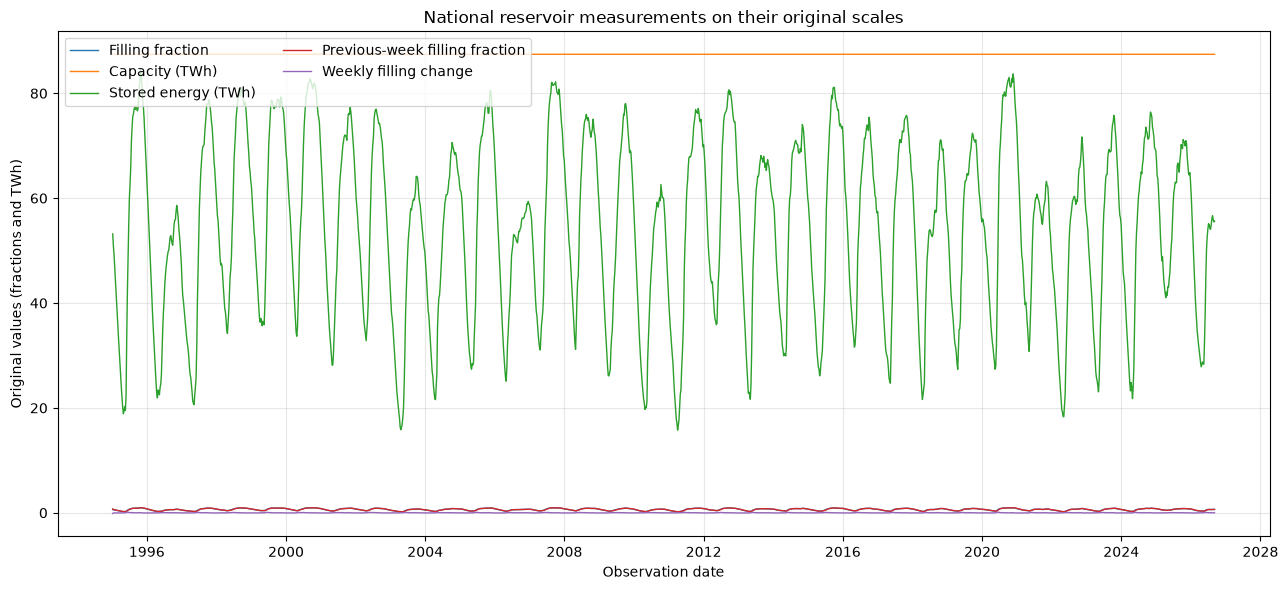

In [11]:
# I deliberately start with the original values so the scale problem is visible.
fig, axis = plt.subplots(figsize=(13, 6))

for column in measurement_columns:
    axis.plot(
        national_data["observation_date"],
        national_data[column],
        label=measurement_labels[column],
        linewidth=1
    )

axis.set_title("National reservoir measurements on their original scales")
axis.set_xlabel("Observation date")
axis.set_ylabel("Original values (fractions and TWh)")
axis.legend(loc="upper left", ncol=2)
axis.grid(alpha=0.3)
plt.tight_layout()
plt.show()

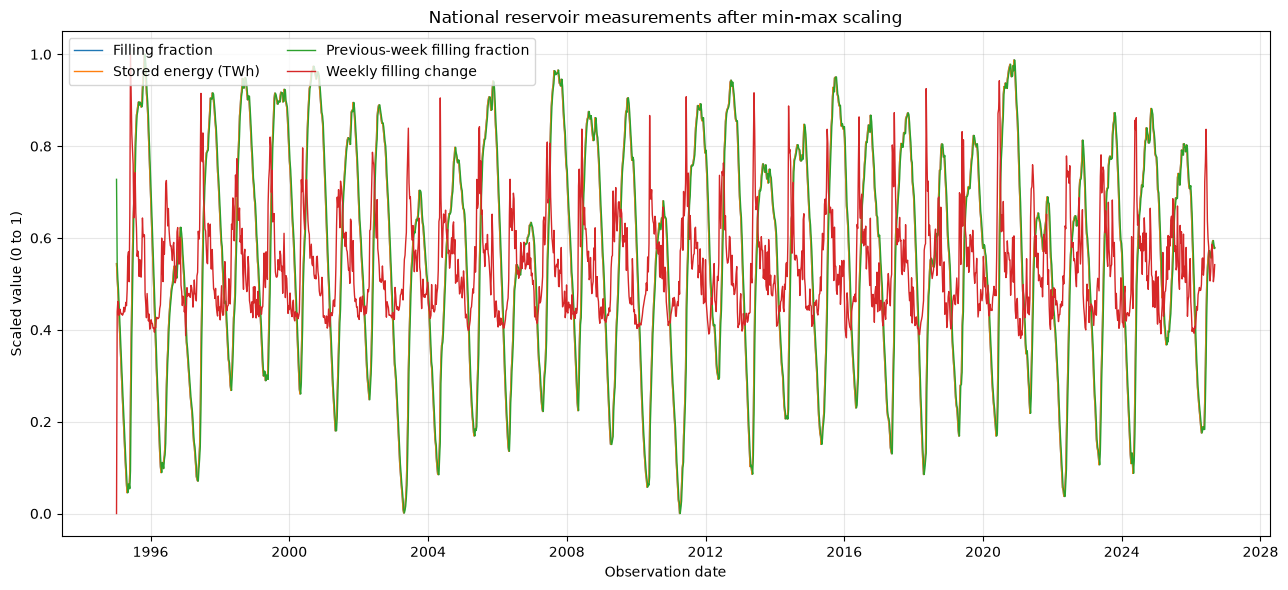

Excluded because the national series is constant: ['capacity_twh']


In [12]:
# Min-max scaling requires variation, so I automatically leave out columns
# that are constant. National capacity is constant in this CSV.
changing_measurements = [
    column for column in measurement_columns
    if national_data[column].nunique() > 1
]

scaled_measurements = national_data[changing_measurements].apply(
    lambda column: (column - column.min()) / (column.max() - column.min())
)

fig, axis = plt.subplots(figsize=(13, 6))

for column in changing_measurements:
    axis.plot(
        national_data["observation_date"],
        scaled_measurements[column],
        label=measurement_labels[column],
        linewidth=1
    )

axis.set_title("National reservoir measurements after min-max scaling")
axis.set_xlabel("Observation date")
axis.set_ylabel("Scaled value (0 to 1)")
axis.legend(loc="upper left", ncol=2)
axis.grid(alpha=0.3)
plt.tight_layout()
plt.show()

excluded_columns = [
    column for column in measurement_columns
    if column not in changing_measurements
]
print("Excluded because the national series is constant:", excluded_columns)

### Interpretation of the combined plots

In the unscaled figure, capacity and stored energy dominate because they are
measured in TWh, while filling fractions and weekly change are much smaller
numbers. The first figure is therefore truthful about the original units but not
very useful for comparing shapes.

The scaled figure makes the patterns comparable. Current and previous-week
filling almost overlap, and stored energy follows the same seasonal pattern.
Weekly change behaves differently because it measures movement from one week to
the next rather than the reservoir level itself. `capacity_twh` is excluded from
the scaled figure because its national value is constant; min-max scaling would
otherwise require division by zero. The separate capacity plot still documents
that column.

## 6. Project documentation

### Work log (current draft)

I started the compulsory work by creating a project structure with separate
folders for the notebook, data, and future Streamlit pages. I installed the
packages from `requirements.txt` and configured the notebook to use the project's
Python 3.12 environment in VS Code. Selecting the correct kernel took some extra
work because VS Code initially continued to show an older Python version. Once
the environment was available as a Jupyter kernel, the notebook ran correctly.

I loaded `reservoirs.csv` with Pandas by using a relative path from the notebook
folder. This makes the project portable because another person can clone the
repository without changing a path tied to my computer. The file contains 14,877
rows and 11 columns. I inspected the original Norwegian headers, their data
types, and example values before renaming the headers to understandable English
names. I checked the meaning of the area codes and variables against NVE's
reservoir-statistics API rather than relying only on direct translation.

The initial missing-value check reported no missing cells, but the publication
date contained `0001-01-01T00:00:00` in many historical rows. I treated this as a
placeholder and kept the raw value unchanged because NVE does not document the
reason for it. I also used distributions and calculation checks to look for other
possible placeholder values. No other clear sentinel was found. Two filling
fractions were slightly above 100%, so I documented them instead of silently
removing them.

For the visual exploration, I used bar charts for categorical and calendar
columns and time-series plots for the measurements. I selected the national
records for the time-series figures because combining national, electricity-price,
and watercourse areas would mix overlapping summaries. I first plotted the
measurements together without scaling, which showed that the TWh columns dominate.
I then used min-max scaling to compare their patterns while keeping the original
data unchanged.

My Streamlit work is currently limited to setting up `main.py`, the `pages`
folder, the local data folder, and the dependency file. The actual four-page app
and deployment have not been completed yet. When that work is finished, I will
update this log with the navigation, caching, table, plotting controls, deployment
experience, and the final public Streamlit link.